In [1]:
# Install required libraries

#!pip install torch torchvision timm matplotlib seaborn scikit-learn opencv-python --quiet

In [2]:
# ── Standard Libraries ─────────────────────────────────────

import os
import random
import warnings

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

warnings.filterwarnings('ignore')

# ── PyTorch ────────────────────────────────────────────────

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ── Vision Transformer ─────────────────────────────────────

import timm

# ── Evaluation ─────────────────────────────────────────────

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

# ── Reproducibility ────────────────────────────────────────

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device Check ───────────────────────────────────────────

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version :", torch.__version__)
print("Using device    :", device)

# ── Output Folder ──────────────────────────────────────────

OUTPUT_DIR = './vit_outputs'

os.makedirs(OUTPUT_DIR, exist_ok=True)

PyTorch version : 2.9.1+cpu
Using device    : cpu



##  Configuration

In [3]:
# ══════════════════════════════════════════════
# CONFIGURATION
# ══════════════════════════════════════════════

# Dataset paths

TRAIN_DIR = r"F:\SPRG-26\ANN\ANN Project\Cervical-Fracture\cervical fracture\train"

VAL_DIR = r"F:\SPRG-26\ANN\ANN Project\Cervical-Fracture\cervical fracture\val"

# Image settings

IMG_SIZE = 224

# Training settings

BATCH_SIZE = 8

NUM_EPOCHS = 3

LEARNING_RATE = 1e-4

NUM_CLASSES = 2

# Class names

CLASS_NAMES = ['fracture', 'normal']

# Model name

MODEL_NAME = 'vit_tiny_patch16_224'

# ══════════════════════════════════════════════

print("✅ Configuration set!")

print(f"Image size   : {IMG_SIZE}x{IMG_SIZE}")

print(f"Batch size   : {BATCH_SIZE}")

print(f"Epochs       : {NUM_EPOCHS}")

print(f"Learning rate: {LEARNING_RATE}")

print(f"Model        : {MODEL_NAME}")

✅ Configuration set!
Image size   : 224x224
Batch size   : 8
Epochs       : 3
Learning rate: 0.0001
Model        : vit_tiny_patch16_224


---
##  Data Preprocessing


In [4]:
# ════════════════════════════════════════════════════════════
# DATA PREPROCESSING & DATASET LOADING
# ════════════════════════════════════════════════════════════

# Training transforms

train_transform = transforms.Compose([
    
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    
    transforms.RandomHorizontalFlip(),
    
    transforms.RandomRotation(20),
    
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    
    transforms.ToTensor(),
])

# Validation transforms

val_transform = transforms.Compose([
    
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    
    transforms.ToTensor(),
])

# ════════════════════════════════════════════════════════════
# LOAD DATASETS
# ════════════════════════════════════════════════════════════

train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    VAL_DIR,
    transform=val_transform
)

# ════════════════════════════════════════════════════════════
# DATALOADERS
# ════════════════════════════════════════════════════════════

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# ════════════════════════════════════════════════════════════
# DATASET INFORMATION
# ════════════════════════════════════════════════════════════

print("✅ Data loaded successfully!")

print(f"Classes        : {train_dataset.classes}")

print(f"Training images: {len(train_dataset)}")

print(f"Validation images: {len(val_dataset)}")

✅ Data loaded successfully!
Classes        : ['fracture', 'normal']
Training images: 3800
Validation images: 400


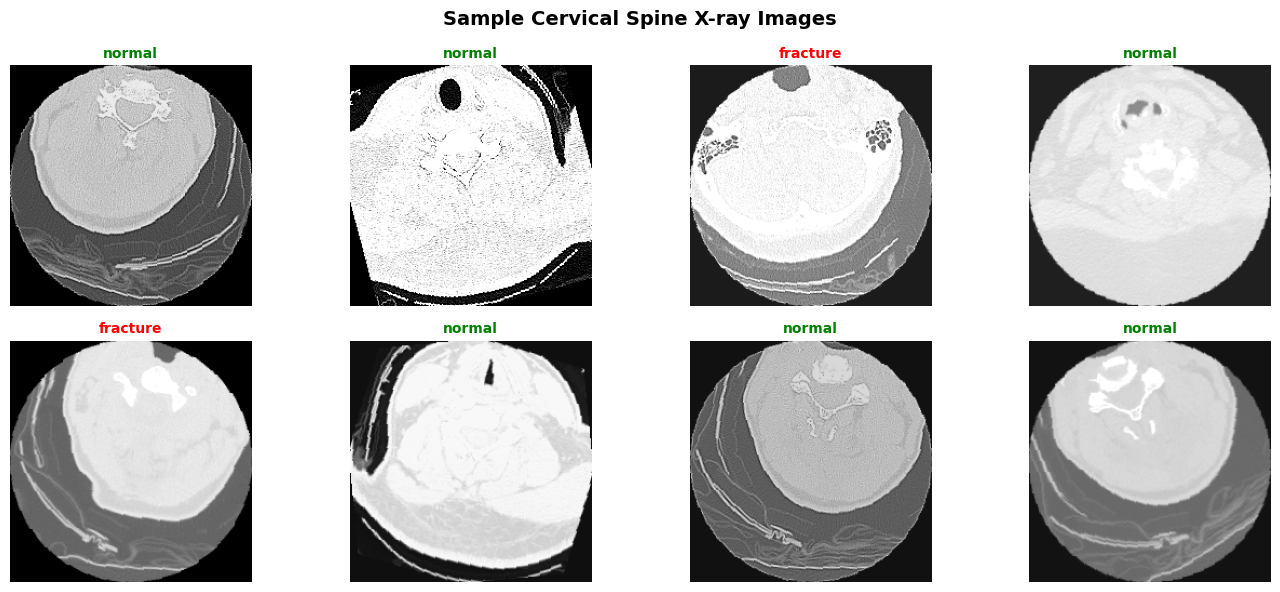

In [5]:
# ───────────────────────────────────────────────────────────
# VISUALIZE SAMPLE X-RAY IMAGES
# ───────────────────────────────────────────────────────────

def show_sample_images(data_loader, title='Sample X-ray Images', n=8):

    images, labels = next(iter(data_loader))

    n = min(n, len(images))

    fig, axes = plt.subplots(2, n//2, figsize=(14, 6))

    fig.suptitle(title, fontsize=14, fontweight='bold')

    for i, ax in enumerate(axes.flat):

        if i >= n:
            ax.axis('off')
            continue

        # Convert tensor → numpy
        image = images[i].permute(1, 2, 0).numpy()

        label = CLASS_NAMES[int(labels[i])]

        color = 'red' if label == 'fracture' else 'green'

        ax.imshow(image)

        ax.set_title(
            label,
            color=color,
            fontsize=10,
            fontweight='bold'
        )

        ax.axis('off')

    plt.tight_layout()

    plt.savefig(
        f'{OUTPUT_DIR}/sample_xray_images.png',
        dpi=150,
        bbox_inches='tight'
    )

    plt.show()

# Show images

show_sample_images(
    train_loader,
    'Sample Cervical Spine X-ray Images'
)

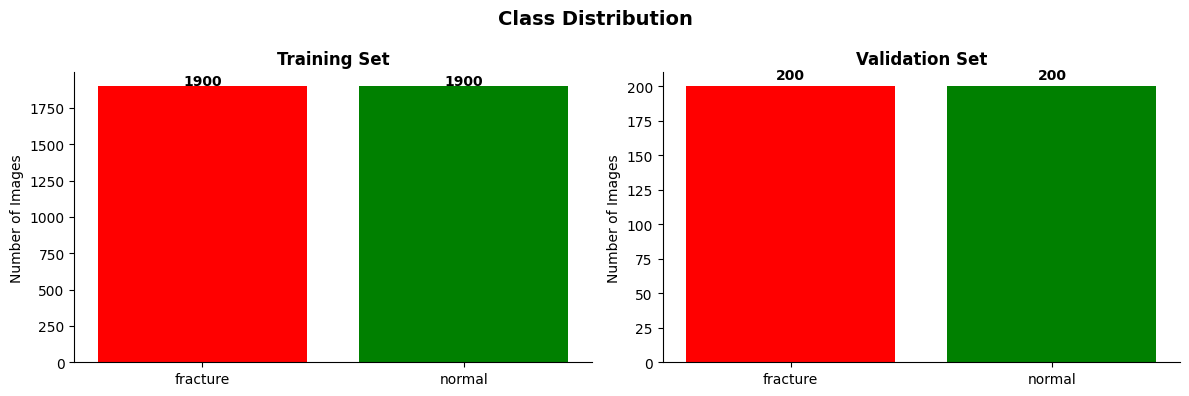

In [6]:
# ───────────────────────────────────────────────────────────
# CLASS DISTRIBUTION VISUALIZATION
# ───────────────────────────────────────────────────────────

import glob

def count_images(directory):

    counts = {}

    for cls in os.listdir(directory):

        cls_path = os.path.join(directory, cls)

        if os.path.isdir(cls_path):

            counts[cls] = len(
                glob.glob(os.path.join(cls_path, '*'))
            )

    return counts

# Count images

train_counts = count_images(TRAIN_DIR)

val_counts = count_images(VAL_DIR)

# ───────────────────────────────────────────────────────────
# PLOT DISTRIBUTION
# ───────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

fig.suptitle(
    'Class Distribution',
    fontsize=14,
    fontweight='bold'
)

colors = ['red', 'green']

for ax, (name, counts) in zip(
    axes,
    [('Training', train_counts), ('Validation', val_counts)]
):

    bars = ax.bar(
        counts.keys(),
        counts.values(),
        color=colors
    )

    ax.set_title(
        f'{name} Set',
        fontweight='bold'
    )

    ax.set_ylabel('Number of Images')

    for bar, value in zip(bars, counts.values()):

        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 5,
            str(value),
            ha='center',
            fontweight='bold'
        )

    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()

plt.savefig(
    f'{OUTPUT_DIR}/class_distribution.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

---
## Vision Transformer Architecture


 

---
##  Training

In [7]:
# ───────────────────────────────────────────────────────────
# LOAD VISION TRANSFORMER MODEL
# ───────────────────────────────────────────────────────────

import timm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vit_model = timm.create_model(
    MODEL_NAME,
    pretrained=True,
    num_classes=NUM_CLASSES
)

vit_model = vit_model.to(device)

print("✅ Vision Transformer loaded!")

print(f"Model: {MODEL_NAME}")

✅ Vision Transformer loaded!
Model: vit_tiny_patch16_224


In [8]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    vit_model.parameters(),
    lr=LEARNING_RATE
)

print("✅ Training configuration completed!")

✅ Training configuration completed!


In [9]:
# ───────────────────────────────────────────────────────────
# MODEL TRAINING
# ───────────────────────────────────────────────────────────

print("🚀 Training Vision Transformer...")

for epoch in range(NUM_EPOCHS):

    vit_model.train()

    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = vit_model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

        # Show progress every 10 batches

        if batch_idx % 10 == 0:

            print(
                f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
                f"Batch [{batch_idx}] "
                f"Loss: {loss.item():.4f}"
            )

    accuracy = 100 * correct / total

    print(f"✅ Epoch {epoch+1} Accuracy = {accuracy:.2f}%")

print("🏆 Training complete!")

🚀 Training Vision Transformer...
Epoch [1/3] Batch [0] Loss: 1.0982
Epoch [1/3] Batch [10] Loss: 0.6553
Epoch [1/3] Batch [20] Loss: 0.3514
Epoch [1/3] Batch [30] Loss: 0.1683
Epoch [1/3] Batch [40] Loss: 0.1637
Epoch [1/3] Batch [50] Loss: 0.0177
Epoch [1/3] Batch [60] Loss: 0.0073
Epoch [1/3] Batch [70] Loss: 0.0061
Epoch [1/3] Batch [80] Loss: 0.0019
Epoch [1/3] Batch [90] Loss: 0.0007
Epoch [1/3] Batch [100] Loss: 0.0015
Epoch [1/3] Batch [110] Loss: 0.3478
Epoch [1/3] Batch [120] Loss: 0.0060
Epoch [1/3] Batch [130] Loss: 0.1639
Epoch [1/3] Batch [140] Loss: 0.0445
Epoch [1/3] Batch [150] Loss: 0.0104
Epoch [1/3] Batch [160] Loss: 0.0314
Epoch [1/3] Batch [170] Loss: 0.0221
Epoch [1/3] Batch [180] Loss: 0.0878
Epoch [1/3] Batch [190] Loss: 0.0177
Epoch [1/3] Batch [200] Loss: 0.0053
Epoch [1/3] Batch [210] Loss: 0.0054
Epoch [1/3] Batch [220] Loss: 0.0050
Epoch [1/3] Batch [230] Loss: 0.0001
Epoch [1/3] Batch [240] Loss: 0.0012
Epoch [1/3] Batch [250] Loss: 0.0001
Epoch [1/3] Batc

---
## Evaluation & Visualizations

In [11]:
# CLASSIFICATION REPORT

y_true = []

y_pred = []

vit_model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        labels = labels.to(device)

        outputs = vit_model(images)

        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())

        y_pred.extend(predicted.cpu().numpy())

# Print report

print("Classification Report\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES
    )
)

Classification Report

              precision    recall  f1-score   support

    fracture       0.88      1.00      0.94       200
      normal       1.00      0.87      0.93       200

    accuracy                           0.94       400
   macro avg       0.94      0.94      0.93       400
weighted avg       0.94      0.94      0.93       400



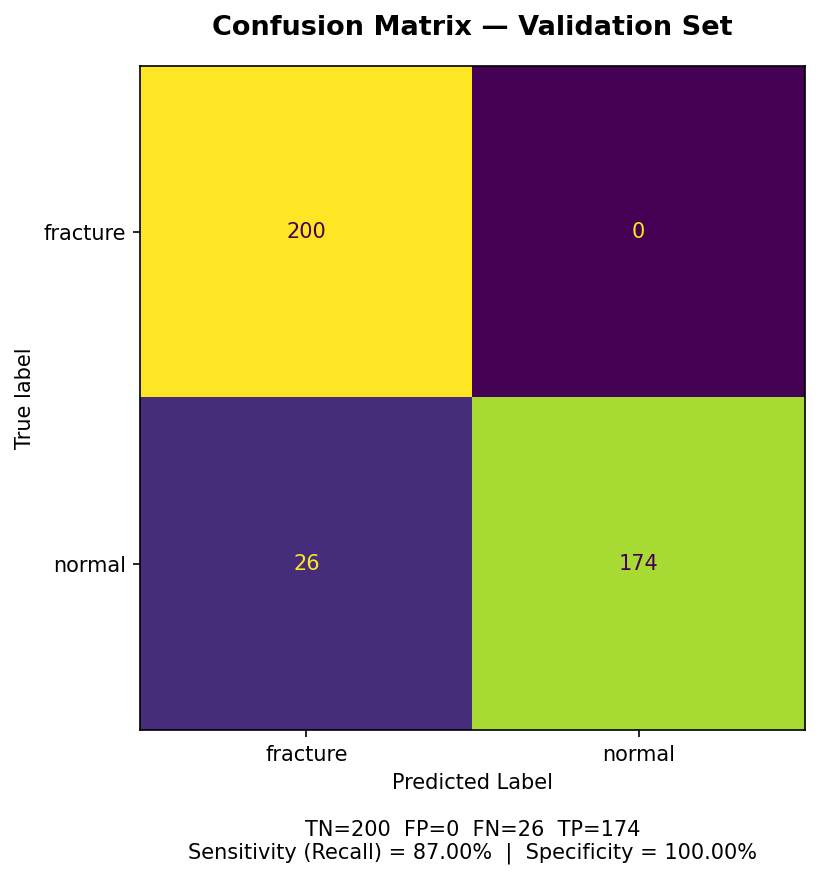


 Medical interpretation:
   Sensitivity (catches real fractures) : 87.00%
   Specificity (avoids false alarms)    : 100.00%
   False Negatives (missed fractures!)  : 26


In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# CONFUSION MATRIX
cm_matrix = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm_matrix.ravel()

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_matrix, display_labels=CLASS_NAMES)
disp.plot(ax=ax, colorbar=False)
ax.set_title('Confusion Matrix — Validation Set',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel(
    f'Predicted Label\n\n'
    f'TN={tn}  FP={fp}  FN={fn}  TP={tp}\n'
    f'Sensitivity (Recall) = {tp/(tp+fn):.2%}  |  Specificity = {tn/(tn+fp):.2%}'
)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.close()  

# ── Display 
from IPython.display import Image as IPImage, display
display(IPImage(f'{OUTPUT_DIR}/confusion_matrix.png'))

print('\n Medical interpretation:')
print(f'   Sensitivity (catches real fractures) : {tp/(tp+fn):.2%}')
print(f'   Specificity (avoids false alarms)    : {tn/(tn+fp):.2%}')
print(f'   False Negatives (missed fractures!)  : {fn}')

---
### INTERPRETABILITY

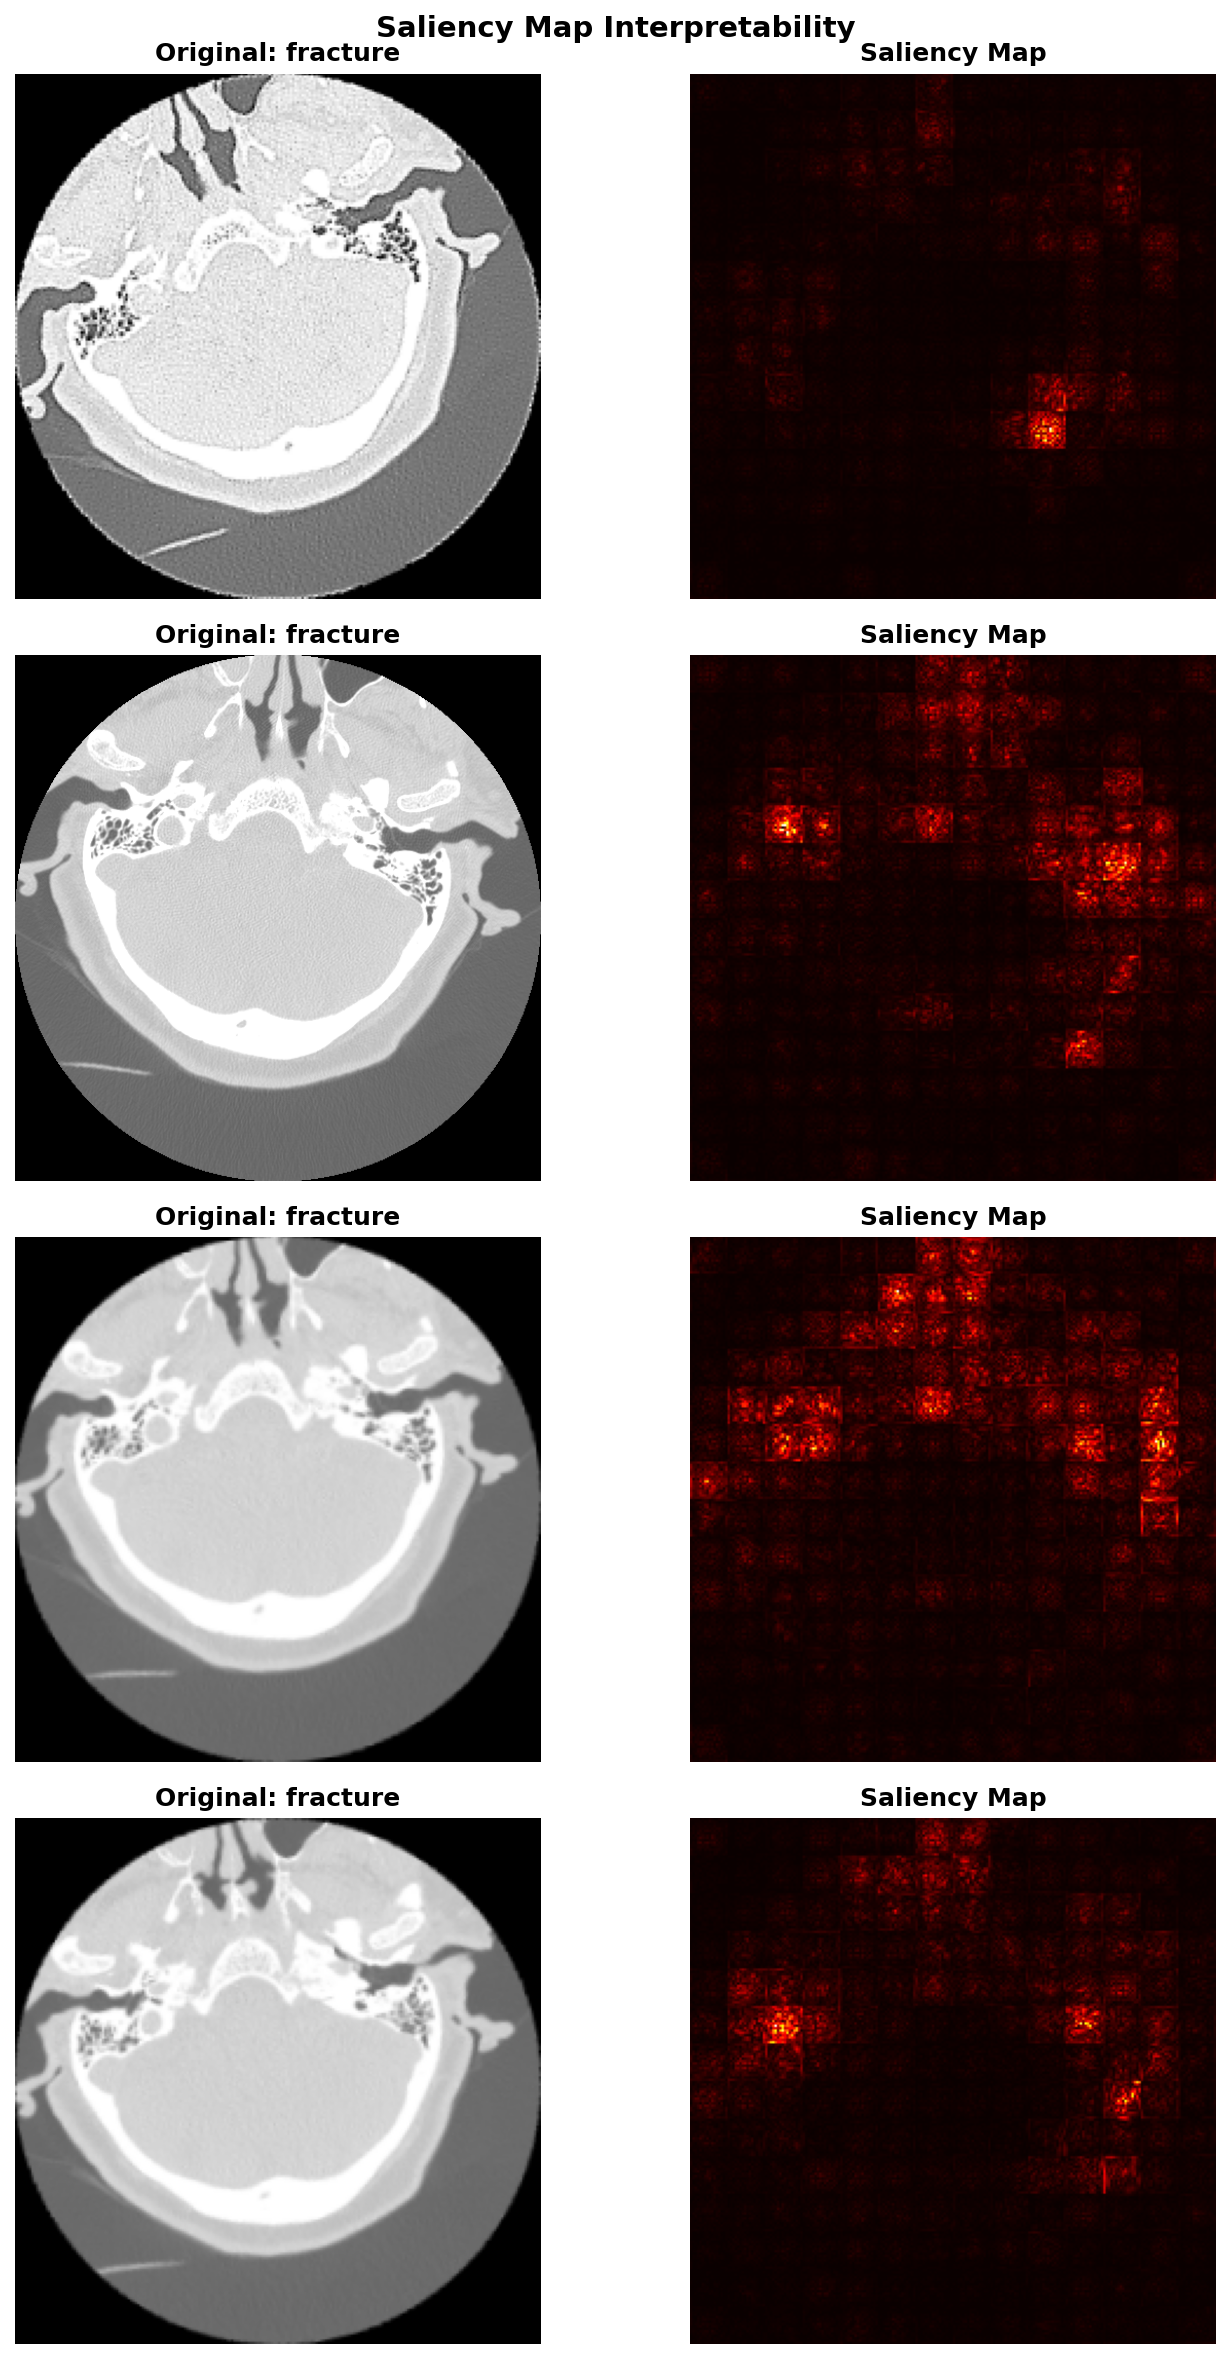

In [15]:
# INTERPRETABILITY USING SALIENCY MAPS

from PIL import Image
from IPython.display import Image as IPImage, display

# Select random validation images
all_images = []

fracture_folder = os.path.join(VAL_DIR, "fracture")

normal_folder = os.path.join(VAL_DIR, "normal")

for folder in [fracture_folder, normal_folder]:

    for img_name in os.listdir(folder):

        all_images.append(os.path.join(folder, img_name))

# Randomly select 4 images
selected_images = random.sample(all_images, 4)

# Create figure
fig, ax = plt.subplots(4, 2, figsize=(10, 16))

fig.suptitle(
    "Saliency Map Interpretability",
    fontsize=14,
    fontweight='bold'
)

# Process each image
for i, image_path in enumerate(selected_images):

    # Load image
    image = Image.open(image_path).convert("RGB")

    # Transform image
    input_tensor = val_transform(image).unsqueeze(0).to(device)

    # Enable gradients
    input_tensor.requires_grad_()

    # Forward pass
    output = vit_model(input_tensor)

    predicted_class = output.argmax(dim=1)

    score = output[0, predicted_class]

    # Backward pass
    vit_model.zero_grad()

    score.backward()

    # Generate saliency map
    saliency = input_tensor.grad.data.abs()

    saliency, _ = torch.max(saliency, dim=1)

    saliency = saliency.squeeze().cpu().numpy()

    # Original image
    ax[i, 0].imshow(image)

    ax[i, 0].set_title(
        f"Original: {os.path.basename(os.path.dirname(image_path))}",
        fontweight='bold'
    )

    ax[i, 0].axis("off")

    # Saliency map
    ax[i, 1].imshow(saliency, cmap='hot')

    ax[i, 1].set_title(
        "Saliency Map",
        fontweight='bold'
    )

    ax[i, 1].axis("off")

# Save figure
plt.tight_layout()

plt.savefig(
    f'{OUTPUT_DIR}/saliency_maps.png',
    dpi=150,
    bbox_inches='tight'
)

plt.close()

# Display image
display(IPImage(f'{OUTPUT_DIR}/saliency_maps.png'))

---
## Summary & Comparison Table

In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
# FINAL RESULTS
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)


print(" FINAL RESULTS SUMMARY")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


 FINAL RESULTS SUMMARY
Accuracy: 0.9350
Precision: 1.0000
Recall: 0.8700
F1 Score: 0.9305
